<a href="https://colab.research.google.com/github/leman-cap13/Machine_Learning/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D


from scipy import stats


from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import (
    StandardScaler,
    PowerTransformer
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler


#Load data

In [61]:
np.random.seed(42)

housing = fetch_california_housing(as_frame=True)
df = housing.frame

df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#Correlation

In [82]:
df.corr(method='kendall')

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.099609,0.470873,-0.170677,0.003885,-0.025733,-0.059947,-0.006248,0.495528
HouseAge,-0.099609,1.000000,-0.157219,-0.082004,-0.197112,-0.016475,0.026044,-0.104427,0.049822
AveRooms,0.470873,-0.157219,1.000000,0.055218,-0.072516,0.018495,0.084683,-0.029806,0.179175
AveBedrms,-0.170677,-0.082004,0.055218,1.000000,0.020396,-0.088062,0.031485,0.006993,-0.083489
Population,0.003885,-0.197112,-0.072516,0.020396,1.000000,0.164131,-0.082507,0.082974,0.002172
AveOccup,-0.025733,-0.016475,0.018495,-0.088062,0.164131,1.000000,-0.102363,0.121651,-0.174370
Latitude,-0.059947,0.026044,0.084683,0.031485,-0.082507,-0.102363,1.000000,-0.692317,-0.109411
Longitude,-0.006248,-0.104427,-0.029806,0.006993,0.082974,0.121651,-0.692317,1.000000,-0.052495
MedHouseVal,0.495528,0.049822,0.179175,-0.083489,0.002172,-0.174370,-0.109411,-0.052495,1.000000


In [83]:
df.corr(method='pearson')

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [86]:
df.corr(method='spearman')

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.147308,0.643671,-0.252426,0.006268,-0.044171,-0.088029,-0.009928,0.676778
HouseAge,-0.147308,1.000000,-0.231409,-0.120981,-0.283879,-0.024833,0.032440,-0.150752,0.074855
AveRooms,0.643671,-0.231409,1.000000,0.082046,-0.105385,0.018807,0.127134,-0.044783,0.263367
AveBedrms,-0.252426,-0.120981,0.082046,1.000000,0.027027,-0.132315,0.047197,0.010884,-0.125187
Population,0.006268,-0.283879,-0.105385,0.027027,1.000000,0.242337,-0.123626,0.123527,0.003839
AveOccup,-0.044171,-0.024833,0.018807,-0.132315,0.242337,1.000000,-0.150954,0.181468,-0.256594
Latitude,-0.088029,0.032440,0.127134,0.047197,-0.123626,-0.150954,1.000000,-0.879203,-0.165739
Longitude,-0.009928,-0.150752,-0.044783,0.010884,0.123527,0.181468,-0.879203,1.000000,-0.069667
MedHouseVal,0.676778,0.074855,0.263367,-0.125187,0.003839,-0.256594,-0.165739,-0.069667,1.000000


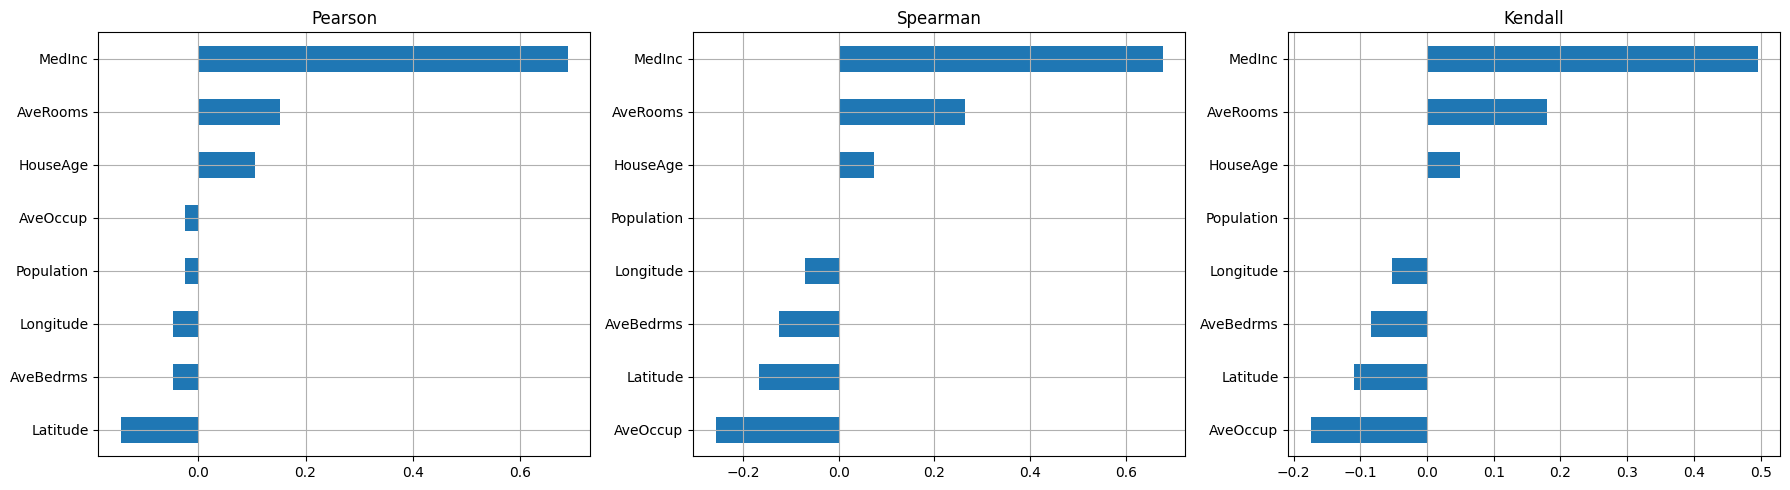

In [62]:
corr_pearson  = df.corr(method="pearson")["MedHouseVal"].drop("MedHouseVal")
corr_spearman = df.corr(method="spearman")["MedHouseVal"].drop("MedHouseVal")
corr_kendall  = df.corr(method="kendall")["MedHouseVal"].drop("MedHouseVal")

fig, axes = plt.subplots(1,3, figsize=(18,5))

corr_pearson.sort_values().plot(kind="barh", ax=axes[0], title="Pearson")
corr_spearman.sort_values().plot(kind="barh", ax=axes[1], title="Spearman")
corr_kendall.sort_values().plot(kind="barh", ax=axes[2], title="Kendall")

for ax in axes:
    ax.grid(True)

plt.tight_layout()
plt.show()


# Skewness kurtosis QQ plot

In [91]:
df.skew(numeric_only=True)

,0
MedInc,1.646657
HouseAge,0.060331
AveRooms,20.697869
AveBedrms,31.316956
Population,4.935858
AveOccup,97.639561
Latitude,0.465953
Longitude,-0.297801
MedHouseVal,0.977763


In [92]:
df.kurtosis(numeric_only=True)

,0
MedInc,4.952524
HouseAge,-0.800629
AveRooms,879.353264
AveBedrms,1636.711972
Population,73.553116
AveOccup,10651.010636
Latitude,-1.117760
Longitude,-1.330152
MedHouseVal,0.327870


Skew: 1.64653702990008


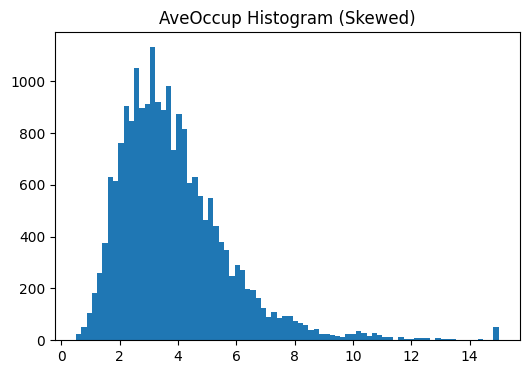

In [97]:
x = df["MedInc"].values

print("Skew:", stats.skew(x))

plt.figure(figsize=(6,4))
plt.hist(x, bins=80)
plt.title("AveOccup Histogram (Skewed)")
plt.show()


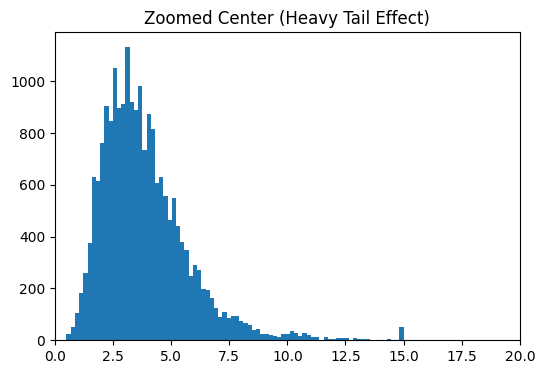

In [98]:
plt.figure(figsize=(6,4))
plt.hist(x, bins=80)
plt.xlim(0, 20)
plt.title("Zoomed Center (Heavy Tail Effect)")
plt.show()


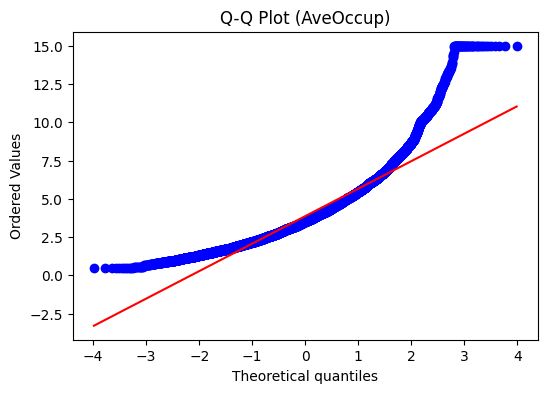

In [99]:
plt.figure(figsize=(6,4))
stats.probplot(x, dist="norm", plot=plt)
plt.title("Q-Q Plot (AveOccup)")
plt.show()


#PowerTransformer

In [104]:
a=[0,2,3]
b=np.log1p(a)
b

array([0.        , 1.09861229, 1.38629436])

In [65]:
feat = "AveOccup"
x = df[feat].values

print("ORIGINAL")
print("Skew:", stats.skew(x))
print("Kurtosis:", stats.kurtosis(x))


ORIGINAL
Skew: 97.63246492211677
Kurtosis: 10648.430333805287


In [66]:
x_log = np.log1p(x)

print("\nLOG1P")
print("Skew:", stats.skew(x_log))
print("Kurtosis:", stats.kurtosis(x_log))



LOG1P
Skew: 3.879396923810052
Kurtosis: 76.97812077483556


In [67]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")
x_yj = pt.fit_transform(x.reshape(-1,1)).ravel()

print("\nYEO-JOHNSON")
print("Skew:", stats.skew(x_yj))
print("Kurtosis:", stats.kurtosis(x_yj))



YEO-JOHNSON
Skew: -0.10687995428516486
Kurtosis: 1.3489674602731228


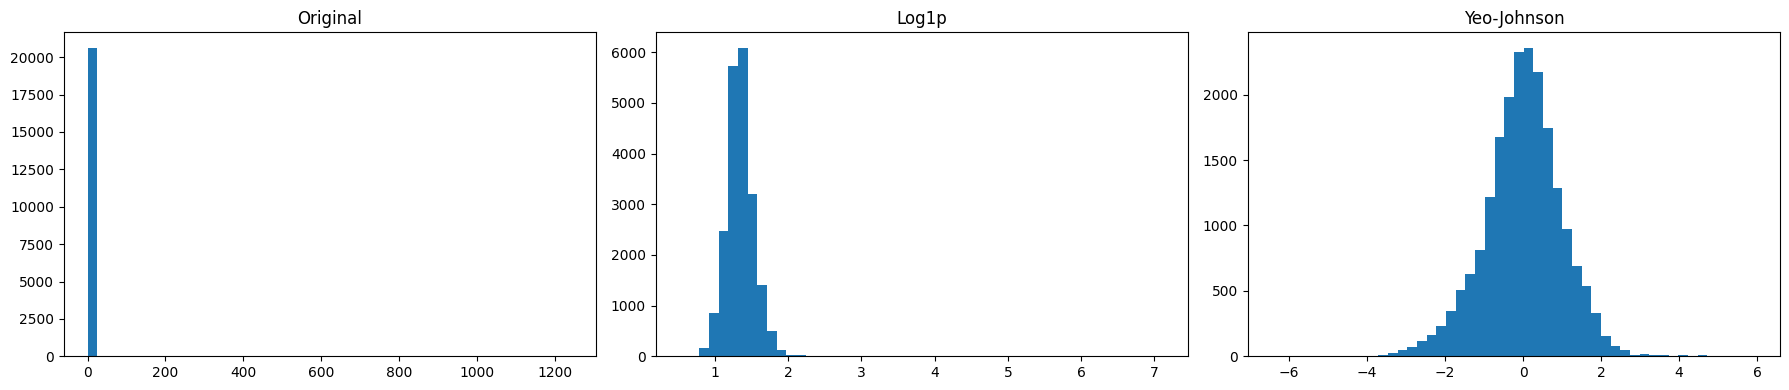

In [68]:
fig, axes = plt.subplots(1,3, figsize=(18,4))

axes[0].hist(x, bins=50)
axes[0].set_title("Original")

axes[1].hist(x_log, bins=50)
axes[1].set_title("Log1p")

axes[2].hist(x_yj, bins=50)
axes[2].set_title("Yeo-Johnson")

plt.tight_layout()
plt.show()


Skew values:
Original: 97.63246492211677
Log1p   : 3.879396923810052
Yeo-John: -0.10687995428516486


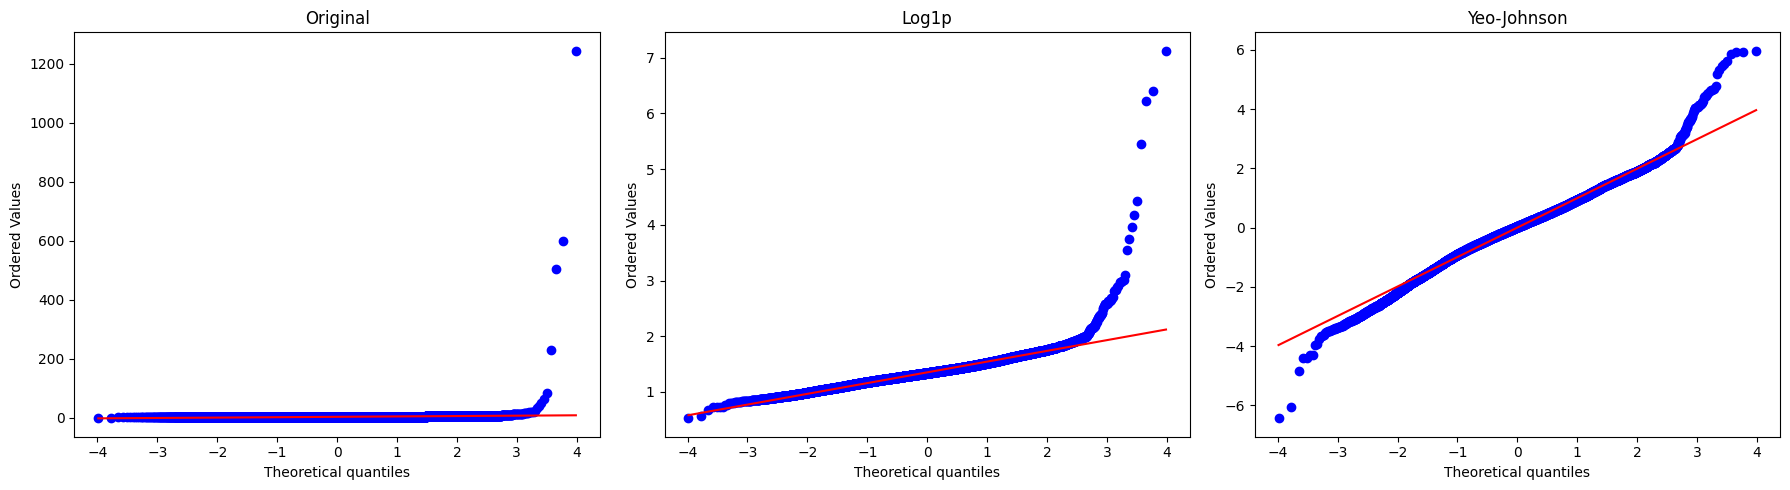

In [69]:
feat = "AveOccup"
x = df[feat].values


x_log = np.log1p(x)

pt = PowerTransformer(method="yeo-johnson")
x_yj = pt.fit_transform(x.reshape(-1,1)).ravel()

print("Skew values:")
print("Original:", stats.skew(x))
print("Log1p   :", stats.skew(x_log))
print("Yeo-John:", stats.skew(x_yj))


fig, axes = plt.subplots(1,3, figsize=(18,5))

stats.probplot(x, dist="norm", plot=axes[0])
axes[0].set_title("Original")

stats.probplot(x_log, dist="norm", plot=axes[1])
axes[1].set_title("Log1p")

stats.probplot(x_yj, dist="norm", plot=axes[2])
axes[2].set_title("Yeo-Johnson")

plt.tight_layout()
plt.show()


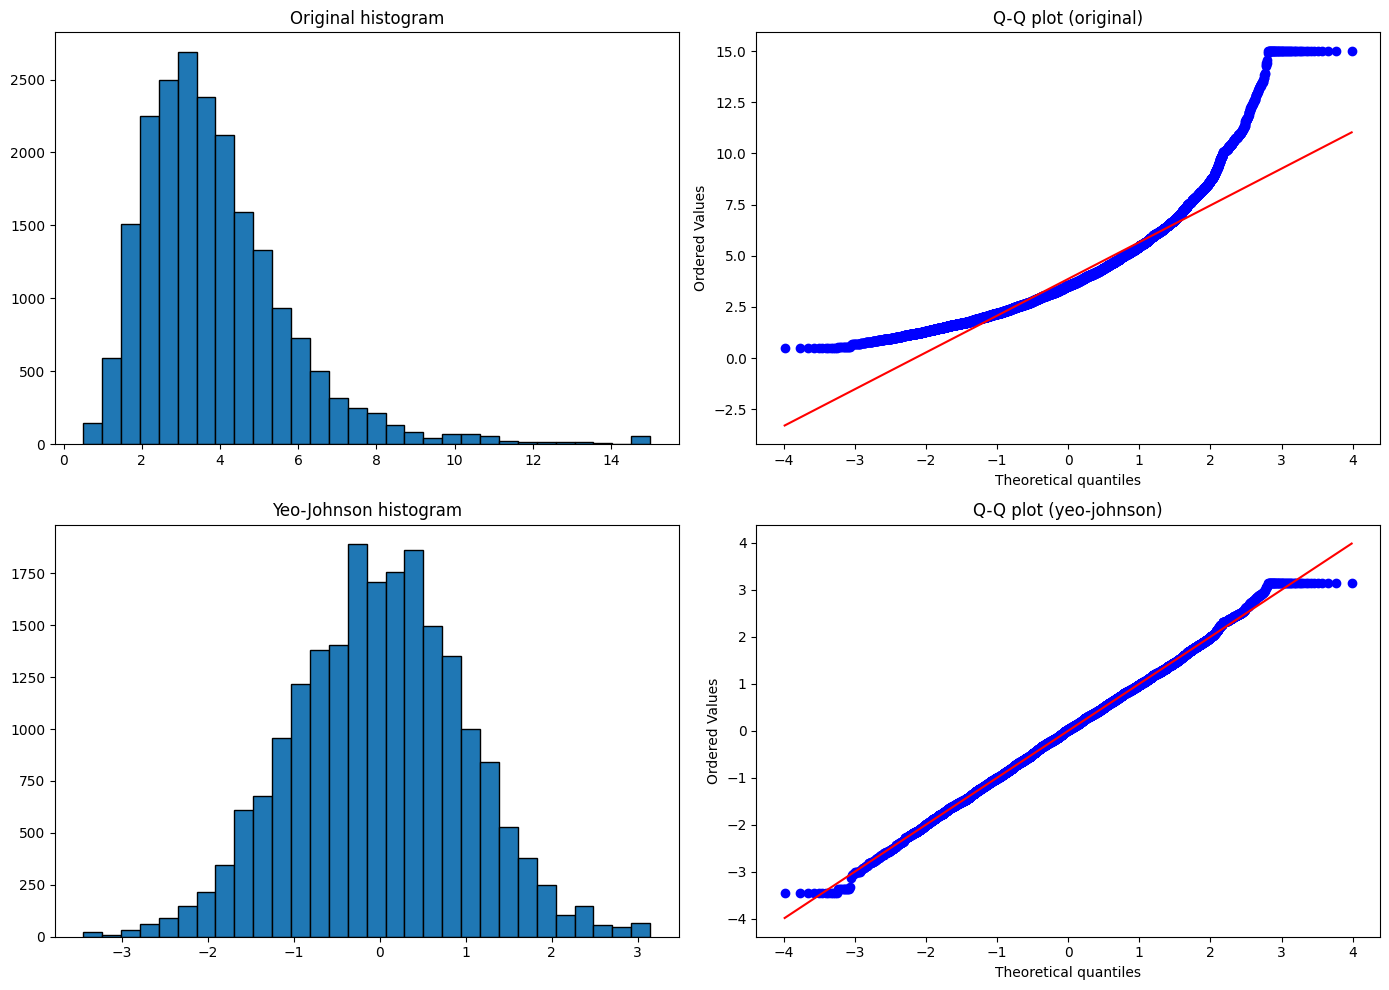

In [70]:
def skew_kurt(x):
    x = np.asarray(x)
    return float(stats.skew(x, nan_policy="omit")), float(stats.kurtosis(x, nan_policy="omit"))

def hist_qq(ax_hist, ax_qq, x, title_prefix):
    ax_hist.hist(x, bins=30, edgecolor="k")
    ax_hist.set_title(f"{title_prefix} histogram")

    stats.probplot(x, dist="norm", plot=ax_qq)
    ax_qq.set_title(f"Q-Q plot ({title_prefix.lower()})")


feat = "MedInc"
x = df[feat].to_numpy()

sk0, ku0 = skew_kurt(x)


pt_yj = PowerTransformer(method="yeo-johnson")
x_yj = pt_yj.fit_transform(x.reshape(-1, 1)).ravel()

lam = float(pt_yj.lambdas_[0])
sk1, ku1 = skew_kurt(x_yj)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

hist_qq(axes[0,0], axes[0,1], x,     "Original")
hist_qq(axes[1,0], axes[1,1], x_yj,  "Yeo-Johnson")

plt.tight_layout()
plt.show()


# Training Model

In [71]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"].copy()

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
num_feature = X_train.select_dtypes(include=[np.number]).columns.tolist()
num_pipeline=Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("std_scaler", StandardScaler())
])

transformer=ColumnTransformer([
    ("num", num_pipeline, num_feature)

])

full_pipeline=Pipeline([
    ("transformer", transformer),
    ("model", LinearRegression())
])

full_pipeline.fit(X_train, y_train)
y_pred=full_pipeline.predict(X_test)
mse=mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 0.56
R-squared: 0.58


In [74]:
skew = X_train.skew(numeric_only=True)

skewed_cols = skew[skew.abs() > 2].index.tolist()
normal_cols = [c for c in X_train.columns if c not in skewed_cols]

print("Skewed cols (|skew| > 2):", skewed_cols)
print("Other cols:", normal_cols)


skewed_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson")),
])

normal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])


transformer = ColumnTransformer(
    transformers=[
        ("skewed", skewed_pipeline, skewed_cols),
        ("normal", normal_pipeline, normal_cols),
    ],
    remainder="drop"
)


model = Pipeline(steps=[
    ("transformer", transformer),
    ("model", LinearRegression()),
])


model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))


Skewed cols (|skew| > 2): ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']
Other cols: ['MedInc', 'HouseAge', 'Latitude', 'Longitude']
R2: 0.6569314457699571


# Eigenvalues Eigenvectors

In [75]:
A = np.array([[2, 1],
              [1, 2]])

eigvals, eigvecs = np.linalg.eig(A)

print("Eigenvalues:", eigvals)
print("Eigenvectors (columns):\n", eigvecs)


Eigenvalues: [3. 1.]
Eigenvectors (columns):
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


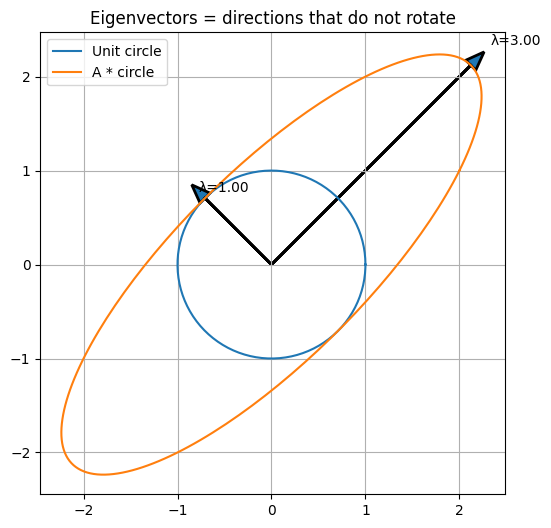

In [76]:
theta = np.linspace(0, 2*np.pi, 200)
circle = np.array([np.cos(theta), np.sin(theta)])

ellipse = A @ circle

plt.figure(figsize=(6,6))
plt.plot(circle[0], circle[1], label="Unit circle")
plt.plot(ellipse[0], ellipse[1], label="A * circle")


for i in range(2):
    v = eigvecs[:, i] * eigvals[i]
    plt.arrow(0, 0, v[0], v[1],
              head_width=0.15, head_length=0.2, linewidth=2)
    plt.text(v[0]*1.1, v[1]*1.1, f"λ={eigvals[i]:.2f}")

plt.axis("equal")
plt.grid(True)
plt.legend()
plt.title("Eigenvectors = directions that do not rotate")
plt.show()


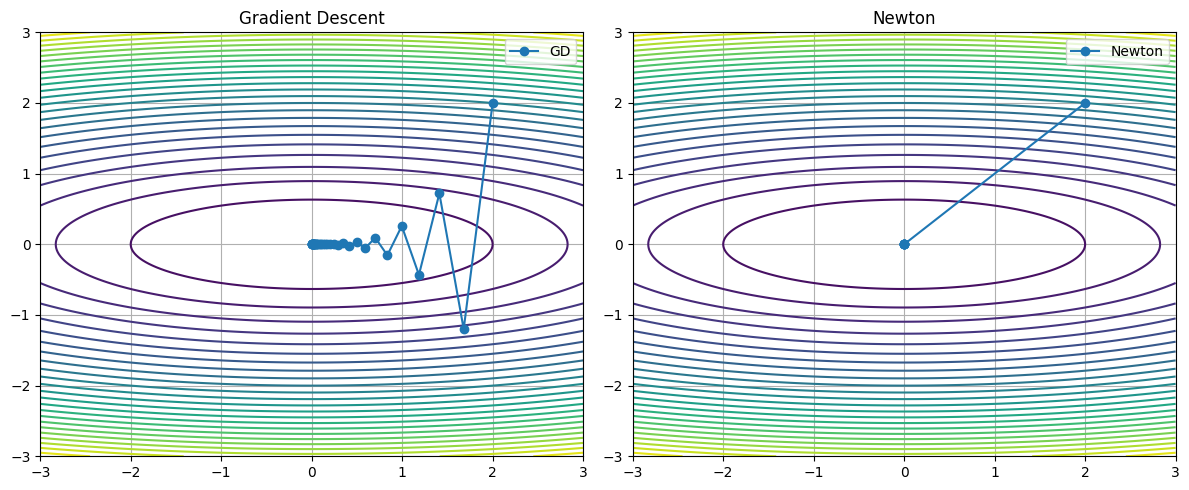

In [77]:
def f(x, y):
    return x**2 + 10*y**2

def grad(v):
    x, y = v
    return np.array([2*x, 20*y])

def hess(v=None):
    return np.array([[2.0, 0.0],
                     [0.0, 20.0]])


def run_gd(x0, lr=0.08, steps=35):
    x = np.array(x0, dtype=float)
    path = [x.copy()]
    for _ in range(steps):
        x = x - lr * grad(x)
        path.append(x.copy())
    return np.array(path)

def run_newton(x0, steps=6):
    x = np.array(x0, dtype=float)
    H = hess()
    path = [x.copy()]
    for _ in range(steps):

        step = np.linalg.solve(H, grad(x))
        x = x - step
        path.append(x.copy())
    return np.array(path)


def contour_grid(xlim=(-3,3), ylim=(-3,3), n=250):
    xs = np.linspace(*xlim, n)
    ys = np.linspace(*ylim, n)
    X, Y = np.meshgrid(xs, ys)
    Z = f(X, Y)
    return X, Y, Z


def plot_path(ax, X, Y, Z, path, title, label):
    ax.contour(X, Y, Z, levels=30)
    ax.plot(path[:,0], path[:,1], "o-", label=label)
    ax.set_title(title)
    ax.grid(True)
    ax.legend()
    ax.set_xlim(X.min(), X.max())
    ax.set_ylim(Y.min(), Y.max())


start = [2.0, 2.0]

path_gd = run_gd(start, lr=0.08, steps=35)
path_nt = run_newton(start, steps=6)

X, Y, Z = contour_grid()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_path(axes[0], X, Y, Z, path_gd, "Gradient Descent", "GD")
plot_path(axes[1], X, Y, Z, path_nt, "Newton", "Newton")

plt.tight_layout()
plt.show()


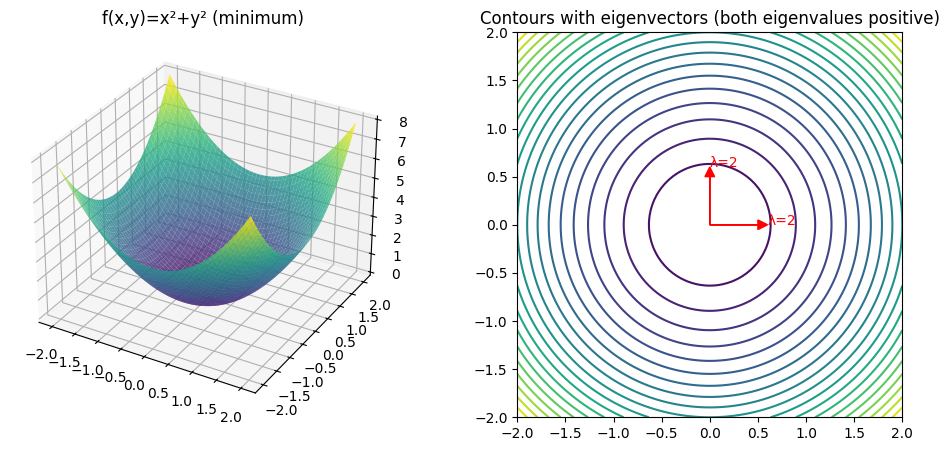

In [78]:
def f_min(x, y):
    return x**2 + y**2

x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)
Z = f_min(X, Y)

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.set_title('f(x,y)=x²+y² (minimum)')

ax2 = fig.add_subplot(122)
contour = ax2.contour(X, Y, Z, levels=20, cmap='viridis')
ax2.set_aspect('equal')
ax2.set_title('Contours with eigenvectors (both eigenvalues positive)')


ax2.arrow(0, 0, 0.5, 0, head_width=0.1, head_length=0.1, fc='red', ec='red')
ax2.arrow(0, 0, 0, 0.5, head_width=0.1, head_length=0.1, fc='red', ec='red')
ax2.text(0.6, 0, 'λ=2', color='red')
ax2.text(0, 0.6, 'λ=2', color='red')
plt.show()

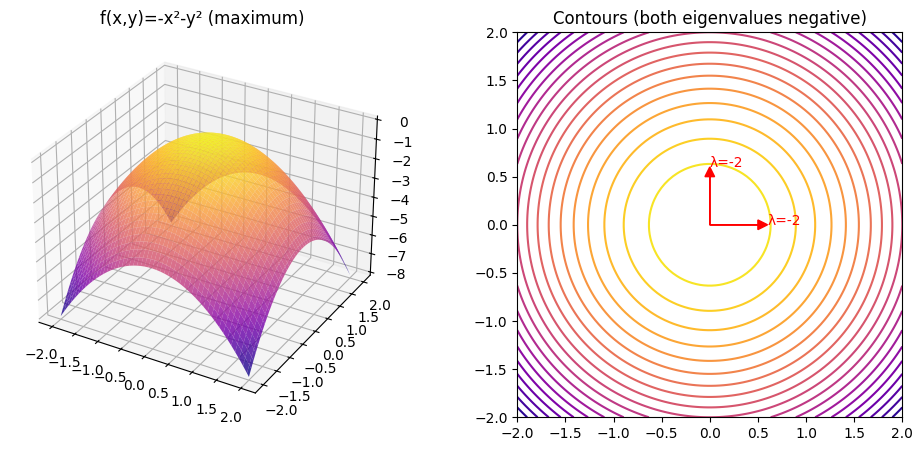

In [79]:
def f_max(x, y):
    return -x**2 - y**2

Z = f_max(X, Y)

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='plasma', alpha=0.8)
ax1.set_title('f(x,y)=-x²-y² (maximum)')

ax2 = fig.add_subplot(122)
contour = ax2.contour(X, Y, Z, levels=20, cmap='plasma')
ax2.set_aspect('equal')
ax2.set_title('Contours (both eigenvalues negative)')
ax2.arrow(0, 0, 0.5, 0, head_width=0.1, head_length=0.1, fc='red', ec='red')
ax2.arrow(0, 0, 0, 0.5, head_width=0.1, head_length=0.1, fc='red', ec='red')
ax2.text(0.6, 0, 'λ=-2', color='red')
ax2.text(0, 0.6, 'λ=-2', color='red')
plt.show()

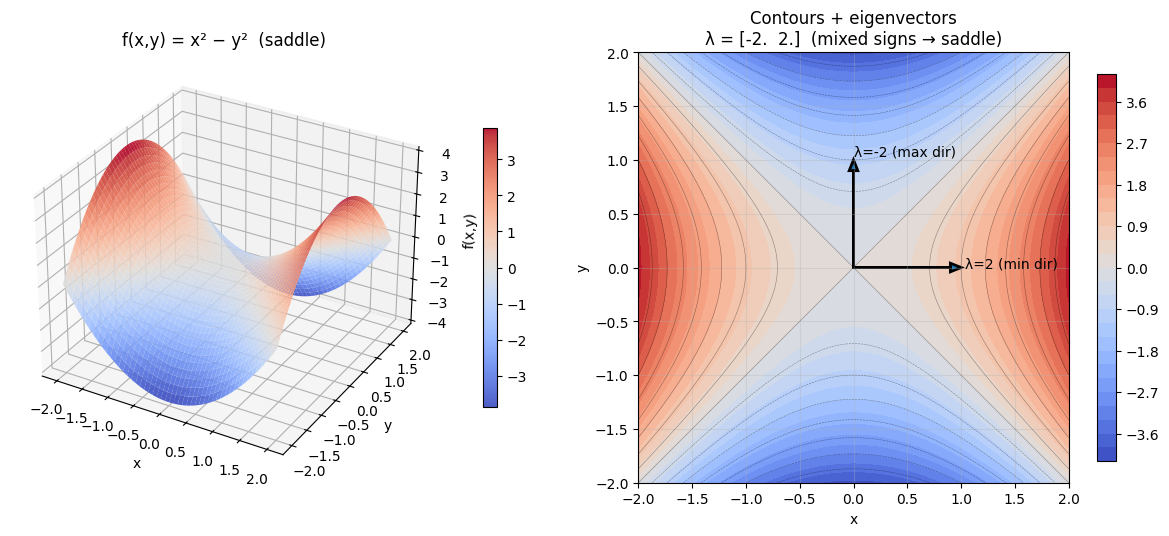

In [80]:
def f_saddle(x, y):
    return x**2 - y**2


x = np.linspace(-2, 2, 200)
y = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(x, y)
Z = f_saddle(X, Y)


H = np.array([[ 2.0, 0.0],
              [ 0.0,-2.0]])
eigvals, eigvecs = np.linalg.eigh(H)


fig = plt.figure(figsize=(12, 5))


ax3d = fig.add_subplot(1, 2, 1, projection="3d")
surf = ax3d.plot_surface(X, Y, Z, cmap="coolwarm", linewidth=0, antialiased=True, alpha=0.9)
ax3d.set_title("f(x,y) = x² − y²  (saddle)")
ax3d.set_xlabel("x"); ax3d.set_ylabel("y"); ax3d.set_zlabel("f(x,y)")
fig.colorbar(surf, ax=ax3d, shrink=0.65, pad=0.08)


ax2d = fig.add_subplot(1, 2, 2)
cs = ax2d.contourf(X, Y, Z, levels=30, cmap="coolwarm")
ax2d.contour(X, Y, Z, levels=15, colors="k", linewidths=0.4, alpha=0.4)
ax2d.set_aspect("equal")
ax2d.set_title(f"Contours + eigenvectors\nλ = {eigvals.round(1)}  (mixed signs → saddle)")
ax2d.set_xlabel("x"); ax2d.set_ylabel("y")
ax2d.grid(True, alpha=0.3)
fig.colorbar(cs, ax=ax2d, shrink=0.9)


arrow_len = 0.9
for i in range(2):
    v = eigvecs[:, i]
    lam = eigvals[i]
    ax2d.arrow(
        0, 0, v[0]*arrow_len, v[1]*arrow_len,
        head_width=0.08, head_length=0.10, linewidth=2
    )
    tag = "min dir" if lam > 0 else "max dir"
    ax2d.text(v[0]*arrow_len*1.15, v[1]*arrow_len*1.15, f"λ={lam:.0f} ({tag})")

plt.tight_layout()
plt.show()
